# **Landmrk Extractor from dataset**

In [27]:
import torch
import torch.nn as nn
from torch import optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
from typing import Tuple, Dict, List
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
from mediapipe.tasks.python import text
from mediapipe.tasks.python import audio
import cv2
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

sys.path.insert(0, '..')

In [28]:
labels_df = pd.read_csv('../dataset/labels.csv')

In [41]:
labels_df.head(3)

,image,label
0,asl-0-augmented-0.jpg,del
1,asl-0-augmented-1.jpg,del
2,asl-0-augmented-2.jpg,del


In [29]:
def normalize_landmarks(landmarks):
    # landmarks shape: (21, 3)
    wrist = landmarks[0]
    
    # Wrist centering
    centered = landmarks - wrist
    
    # Scale normalization
    # Calculate Euclidean distance for all points from the new origin
    distances = np.linalg.norm(centered, axis=1)
    max_dist = np.max(distances)
    
    # Avoid division by zero
    if max_dist == 0:
        return centered
        
    normalized = centered / max_dist
    return normalized

Landmarks detected!
<class 'mediapipe.tasks.python.components.containers.landmark.NormalizedLandmark'>
NormalizedLandmark(x=0.3998647630214691, y=0.3238876163959503, z=1.9731791667254583e-07, visibility=None, presence=None, name=None)
21


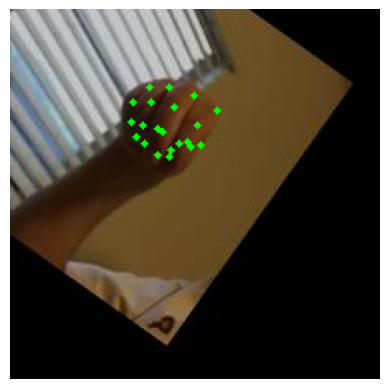

Original landmarks:
 [[ 3.99864763e-01  3.23887616e-01  1.97317917e-07]
 [ 4.78714228e-01  3.58148485e-01 -4.60653529e-02]
 [ 5.13942540e-01  3.66214484e-01 -8.83370042e-02]
 [ 4.88233775e-01  3.73510182e-01 -1.27053440e-01]
 [ 4.33349371e-01  3.83918643e-01 -1.65612340e-01]
 [ 5.58426619e-01  2.72547245e-01 -9.42052305e-02]
 [ 5.05591989e-01  3.15575391e-01 -1.48431167e-01]
 [ 4.57452506e-01  3.63283783e-01 -1.83742285e-01]
 [ 4.29104179e-01  4.00077075e-01 -2.06400946e-01]
 [ 4.97594774e-01  2.33903974e-01 -9.93330702e-02]
 [ 4.43622947e-01  2.63792545e-01 -1.54477924e-01]
 [ 4.10894930e-01  3.33772182e-01 -1.71550065e-01]
 [ 3.98604751e-01  3.93537641e-01 -1.81175396e-01]
 [ 4.32339728e-01  2.13382453e-01 -1.06809497e-01]
 [ 3.80496085e-01  2.53760248e-01 -1.56143084e-01]
 [ 3.61418337e-01  3.16728950e-01 -1.55336350e-01]
 [ 3.62686515e-01  3.65757227e-01 -1.48630917e-01]
 [ 3.76308382e-01  2.10410774e-01 -1.18687660e-01]
 [ 3.33444595e-01  2.53323257e-01 -1.45736933e-01]
 [ 3.29967

In [43]:
# try using mediapipe to extract landmarks from an image and test the normalization function
landmarker_path = '../hand_landmarker/hand_landmarker.task'
base_options = python.BaseOptions(model_asset_path=landmarker_path)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

image_path = '../dataset/images/' + labels_df['image'].iloc[2000]
img = mp.Image.create_from_file(image_path)
results = detector.detect(img)
landmarks = []
if results.hand_landmarks:
    print("Landmarks detected!")
    print(type(results.hand_landmarks[0][0]))
    print(results.hand_landmarks[0][0])
    print(len(results.hand_landmarks[0]))

    for lm in results.hand_landmarks[0]:
        # print(lm.x, lm.y, lm.z)
        landmarks.append([lm.x, lm.y, lm.z])

    # visualize the landmarks
    img_cv = cv2.imread(image_path)
    for lm in results.hand_landmarks[0]:
        x = int(lm.x * img_cv.shape[1])
        y = int(lm.y * img_cv.shape[0])
        cv2.circle(img_cv, (x, y), 2, (0, 255, 0), -1)
    plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

landmarks = np.array(landmarks)
print("Original landmarks:\n", landmarks)
normalized_landmarks = normalize_landmarks(landmarks)
print("Normalized landmarks:\n", normalized_landmarks)

In [31]:
landmark_df = pd.DataFrame({
    'image': [],
    'label': [],
    'landmarks': [],
    'normalized_landmarks': []
})

In [32]:
# try using mediapipe to extract landmarks from an image and test the normalization function
landmarker_path = '../hand_landmarker/hand_landmarker.task'
base_options = python.BaseOptions(model_asset_path=landmarker_path)
options = vision.HandLandmarkerOptions(base_options=base_options, num_hands=1)
detector = vision.HandLandmarker.create_from_options(options)

image_paths = labels_df['image'].to_list()
labels = labels_df['label'].to_list()

for i, image_path in enumerate(tqdm(image_paths)):
    img = mp.Image.create_from_file('../dataset/images/' + image_path)
    label = labels[i]

    results = detector.detect(img)
    if results.hand_landmarks:
        landmarks = []
        for lm in results.hand_landmarks[0]:
            landmarks.append([lm.x, lm.y, lm.z])
        landmarks = np.array(landmarks)
        normalized_landmarks = normalize_landmarks(landmarks)
    elif label == 'nothing':
        normalized_landmarks = np.zeros((21, 3))  # No landmarks detected, use zeros
        
    new_landmark = pd.DataFrame({
        'image': [image_path],
        'label': [label],
        'landmarks': [landmarks],
        'normalized_landmarks': [normalized_landmarks]
    })
    landmark_df = pd.concat([landmark_df, new_landmark], ignore_index=True)

100%|██████████| 107260/107260 [42:54<00:00, 41.66it/s] 


In [42]:
landmark_df.head(3)

,image,label,landmarks,normalized_landmarks,landmarks_flat,normalized_landmarks_flat
0,asl-0-augmented-0.jpg,del,"[[0.3998647630214691, 0.3238876163959503, 1.97...","[[0.0, 0.0, 0.0], [0.3552599221777102, 0.15436...","[0.3998647630214691, 0.3238876163959503, 1.973...","[0.0, 0.0, 0.0, 0.3552599221777102, 0.15436393..."
1,asl-0-augmented-1.jpg,del,"[[0.5381386280059814, 0.10483518242835999, 1.0...","[[0.0, 0.0, 0.0], [0.09607725194118076, 0.0151...","[0.5381386280059814, 0.10483518242835999, 1.00...","[0.0, 0.0, 0.0, 0.09607725194118076, 0.0151670..."
2,asl-0-augmented-2.jpg,del,"[[0.6720114946365356, 0.4920685291290283, 9.84...","[[0.0, 0.0, 0.0], [-0.08181251538453072, 0.021...","[0.6720114946365356, 0.4920685291290283, 9.840...","[0.0, 0.0, 0.0, -0.08181251538453072, 0.021777..."


In [33]:
landmark_df.tail(3)

,image,label,landmarks,normalized_landmarks
107257,hsg-25944-augmented-1.jpg,z,"[[0.5981937050819397, 0.5542265176773071, 1.63...","[[0.0, 0.0, 0.0], [0.08127965204400837, -0.084..."
107258,hsg-25944-augmented-2.jpg,z,"[[0.5981937050819397, 0.5542265176773071, 1.63...","[[0.0, 0.0, 0.0], [0.08127965204400837, -0.084..."
107259,hsg-25944-augmented-3.jpg,z,"[[0.8645024299621582, 0.5645607709884644, 5.72...","[[0.0, 0.0, 0.0], [-0.0774280161968018, 0.1232..."


In [34]:
landmark_df['landmarks'][0].shape

(21, 3)

In [35]:
# flatten the landmarks for easier model input
landmark_df['landmarks_flat'] = landmark_df['landmarks'].apply(lambda x: x.flatten().tolist())
landmark_df['normalized_landmarks_flat'] = landmark_df['normalized_landmarks'].apply(lambda x: x.flatten().tolist())

In [36]:
landmark_df.head()

,image,label,landmarks,normalized_landmarks,landmarks_flat,normalized_landmarks_flat
0,asl-0-augmented-0.jpg,del,"[[0.3998647630214691, 0.3238876163959503, 1.97...","[[0.0, 0.0, 0.0], [0.3552599221777102, 0.15436...","[0.3998647630214691, 0.3238876163959503, 1.973...","[0.0, 0.0, 0.0, 0.3552599221777102, 0.15436393..."
1,asl-0-augmented-1.jpg,del,"[[0.5381386280059814, 0.10483518242835999, 1.0...","[[0.0, 0.0, 0.0], [0.09607725194118076, 0.0151...","[0.5381386280059814, 0.10483518242835999, 1.00...","[0.0, 0.0, 0.0, 0.09607725194118076, 0.0151670..."
2,asl-0-augmented-2.jpg,del,"[[0.6720114946365356, 0.4920685291290283, 9.84...","[[0.0, 0.0, 0.0], [-0.08181251538453072, 0.021...","[0.6720114946365356, 0.4920685291290283, 9.840...","[0.0, 0.0, 0.0, -0.08181251538453072, 0.021777..."
3,asl-0-augmented-3.jpg,del,"[[0.8206281661987305, 0.7975572943687439, 1.79...","[[0.0, 0.0, 0.0], [-0.035006973106454155, -0.0...","[0.8206281661987305, 0.7975572943687439, 1.793...","[0.0, 0.0, 0.0, -0.035006973106454155, -0.0564..."
4,asl-1-augmented-0.jpg,del,"[[0.8206281661987305, 0.7975572943687439, 1.79...","[[0.0, 0.0, 0.0], [-0.035006973106454155, -0.0...","[0.8206281661987305, 0.7975572943687439, 1.793...","[0.0, 0.0, 0.0, -0.035006973106454155, -0.0564..."


In [37]:
landmark_flatten_df = landmark_df[['image', 'label', 'landmarks_flat', 'normalized_landmarks_flat']]

In [38]:
landmark_flatten_df.to_parquet('../dataset/labels_with_landmarks_v2.parquet', index=False)

In [39]:
image_path = '../dataset/images/' + labels_df['image'].iloc[-1]
img = mp.Image.create_from_file(image_path)
results = detector.detect(img)
landmarks = []
if results.hand_landmarks:
    print("Landmarks detected!")
    print(type(results.hand_landmarks[0][0]))
    print(results.hand_landmarks[0][0])
    print(len(results.hand_landmarks[0]))

    for lm in results.hand_landmarks[0]:
        # print(lm.x, lm.y, lm.z)
        landmarks.append([lm.x, lm.y, lm.z])
    landmarks = np.array(landmarks)
    norm_landmarks = normalize_landmarks(landmarks)

    # visualize the landmarks
    # img_cv = cv2.imread(image_path)
    # for lm in results.hand_landmarks[0]:
    #     x = int(lm.x * img_cv.shape[1])
    #     y = int(lm.y * img_cv.shape[0])
    #     cv2.circle(img_cv, (x, y), 2, (0, 255, 0), -1)
    # plt.imshow(cv2.cvtColor(img_cv, cv2.COLOR_BGR2RGB))
    # plt.axis('off')
    # plt.show()

# verify that the landmarks in the csv file are correct
last_row = landmark_df.iloc[-1]
last_row_norm_landmarks = last_row['normalized_landmarks']
last_row_landmarks = last_row['landmarks']
print("Norm Landmarks from CSV:", last_row_norm_landmarks)
print("Norm Landmarks from Mediapipe:", norm_landmarks)

Landmarks detected!
<class 'mediapipe.tasks.python.components.containers.landmark.NormalizedLandmark'>
NormalizedLandmark(x=0.8645024299621582, y=0.5645607709884644, z=5.725326559513633e-07, visibility=None, presence=None, name=None)
21
Norm Landmarks from CSV: [[ 0.          0.          0.        ]
 [-0.07742802  0.1232675  -0.29780971]
 [-0.20162284  0.10129338 -0.45549315]
 [-0.29175995 -0.09006124 -0.57577176]
 [-0.36929535 -0.3100622  -0.67640287]
 [-0.6548812  -0.07020357 -0.25844939]
 [-0.83806869 -0.28903899 -0.43466725]
 [-0.72267048 -0.3809183  -0.57675699]
 [-0.56647026 -0.43020104 -0.66693337]
 [-0.59989316 -0.24407743 -0.18086688]
 [-0.76537603 -0.47568404 -0.36425284]
 [-0.58308742 -0.53526559 -0.49181998]
 [-0.40454419 -0.51321862 -0.56227819]
 [-0.51432125 -0.36713523 -0.13379416]
 [-0.67258622 -0.5828838  -0.29076341]
 [-0.5332003  -0.61737153 -0.35613166]
 [-0.38522131 -0.56171581 -0.37952765]
 [-0.41799001 -0.43877508 -0.11300864]
 [-0.53391753 -0.6055668  -0.2508875

In [40]:
print("Landmarks from CSV:", last_row_landmarks)
print("Landmarks from Mediapipe:", landmarks)

Landmarks from CSV: [[ 8.64502430e-01  5.64560771e-01  5.72532656e-07]
 [ 8.29949021e-01  6.19570732e-01 -1.32901460e-01]
 [ 7.74525225e-01  6.09764457e-01 -2.03270048e-01]
 [ 7.34300196e-01  5.24369597e-01 -2.56946176e-01]
 [ 6.99698865e-01  4.26190883e-01 -3.01854312e-01]
 [ 5.72251916e-01  5.33231378e-01 -1.15336329e-01]
 [ 4.90501761e-01  4.35572803e-01 -1.93976179e-01]
 [ 5.41999936e-01  3.94570291e-01 -2.57385850e-01]
 [ 6.11706614e-01  3.72577131e-01 -2.97628403e-01]
 [ 5.96791148e-01  4.55637574e-01 -8.07139724e-02]
 [ 5.22941947e-01  3.52279663e-01 -1.62552699e-01]
 [ 6.04290962e-01  3.25690508e-01 -2.19481438e-01]
 [ 6.83968544e-01  3.35529298e-01 -2.50924468e-01]
 [ 6.34978890e-01  4.00721192e-01 -5.97070679e-02]
 [ 5.64350784e-01  3.04440171e-01 -1.29756942e-01]
 [ 6.26553833e-01  2.89049506e-01 -1.58928499e-01]
 [ 6.92591667e-01  3.13886702e-01 -1.69369310e-01]
 [ 6.77968144e-01  3.68750840e-01 -5.04312217e-02]
 [ 6.26233757e-01  2.94317544e-01 -1.11961722e-01]
 [ 6.625300